In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [ ]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train)

In [ ]:
cnn_model = models.Sequential()

cnn_model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
cnn_model.add(layers.MaxPooling2D((2,2)))

cnn_model.add(layers.Conv2D(64,(3,3),activation='relu'))
cnn_model.add(layers.MaxPooling2D((2,2)))

cnn_model.add(layers.Flatten())

cnn_model.add(layers.Dense(128,activation='relu'))
cnn_model.add(layers.Dense(10,activation='softmax'))

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = cnn_model.fit(
    datagen.flow(X_train,y_train,batch_size=32),
    epochs=10,
    validation_data=(X_val,y_val)
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.6737 - loss: 1.9269 - val_accuracy: 0.8090 - val_loss: 0.5074
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.7897 - loss: 0.5551 - val_accuracy: 0.8493 - val_loss: 0.4165
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.8101 - loss: 0.4928 - val_accuracy: 0.8327 - val_loss: 0.4856
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.8267 - loss: 0.4529 - val_accuracy: 0.8468 - val_loss: 0.4143
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8327 - loss: 0.4367 - val_accuracy: 0.8549 - val_loss: 0.3820
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.8443 - loss: 0.4143 - val_accuracy: 0.8641 - val_loss: 0.3736
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8449 - loss: 0.4102 - val_accuracy: 0.8802 - val_loss: 0.3383
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.8514 - loss: 0.38

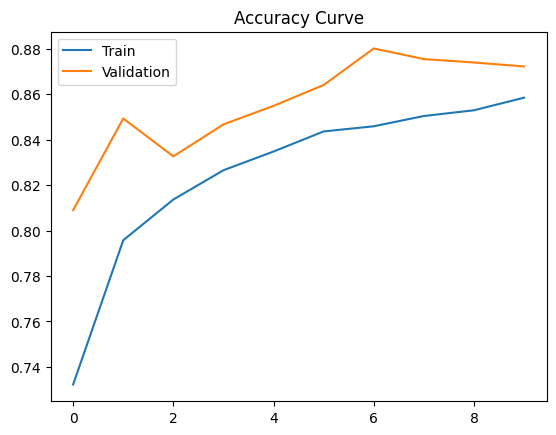

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy Curve")
plt.legend(["Train","Validation"])
plt.show()

In [ ]:
y_pred = cnn_model.predict(X_test)
y_pred_classes = np.argmax(y_pred,axis=1)

print(classification_report(y_test,y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
              precision    recall  f1-score   support

           0       0.80      0.84      0.82      1000
           1       1.00      0.97      0.98      1000
           2       0.77      0.84      0.80      1000
           3       0.83      0.90      0.87      1000
           4       0.83      0.65      0.73      1000
           5       0.97      0.98      0.98      1000
           6       0.62      0.65      0.64      1000
           7       0.94      0.97      0.96      1000
           8       0.98      0.96      0.97      1000
           9       0.98      0.95      0.96      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



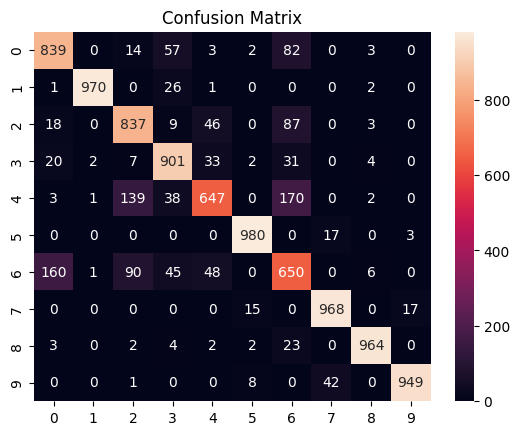

In [ ]:
cm = confusion_matrix(y_test,y_pred_classes)

sns.heatmap(cm,annot=True,fmt="d")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(96,96,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
X_train_t = tf.image.resize(X_train,(96,96))
X_test_t = tf.image.resize(X_test,(96,96))

X_train_t = tf.image.grayscale_to_rgb(X_train_t)
X_test_t = tf.image.grayscale_to_rgb(X_test_t)

In [ ]:
transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
transfer_model.fit(
    X_train_t,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - accuracy: 0.7942 - loss: 0.5701 - val_accuracy: 0.8654 - val_loss: 0.3517
Epoch 2/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.8738 - loss: 0.3385 - val_accuracy: 0.8813 - val_loss: 0.3182
Epoch 3/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.8833 - loss: 0.3098 - val_accuracy: 0.8816 - val_loss: 0.3276
Epoch 4/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.8943 - loss: 0.2812 - val_accuracy: 0.8859 - val_loss: 0.3100
Epoch 5/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9029 - loss: 0.2628 - val_accuracy: 0.8908 - val_loss: 0.3040


In [ ]:
transfer_model.evaluate(X_test_t,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.8851 - loss: 0.3322


[0.3266758322715759, 0.8859000205993652]